Multiple-Feature Regression (Multivariate Regression)

Concept: Use two or more features to predict the target.

📊 Example: Predict house price (Y) using median_income, total_rooms, population, etc.

📉 Equation: 𝑌 = 𝑤 1 𝑋 1 + 𝑤 2 𝑋2 + ⋯ + 𝑤𝑛 𝑋𝑛 + 𝑏

Pycharm IDE - debugging, gui

Anaconda IDE - Jupyter notebook, jupyter lab

VS Code IDE - Python

Students : library

Advantages:

Captures complex relationships between inputs and output.
Typically higher accuracy for real-world problems.
More flexibility and generalization.
Limitations:

Hard to visualize (requires higher-dimensional plots).
Risk of overfitting if too many features are used without regularization or enough data.
Double-click (or enter) to edit

In [62]:
import tensorflow as tf  #Deep learning framework
from tensorflow import keras

print(tf.__version__)
print(keras.__version__)
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd


2.21.0
3.15.0


In [63]:
housing=pd.read_csv(r"C:\Users\sudar\Documents\Collage\Placement prep\Machine learing and computer vison\Lab 2\housing.csv")

#display entire data frame, few rows and columns, top 5 and bottom 5
housing

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY
...,...,...,...,...,...,...,...,...,...,...
20635,-121.09,39.48,25.0,1665.0,374.0,845.0,330.0,1.5603,78100.0,INLAND
20636,-121.21,39.49,18.0,697.0,150.0,356.0,114.0,2.5568,77100.0,INLAND
20637,-121.22,39.43,17.0,2254.0,485.0,1007.0,433.0,1.7000,92300.0,INLAND
20638,-121.32,39.43,18.0,1860.0,409.0,741.0,349.0,1.8672,84700.0,INLAND


Remove the column features

In [64]:
housing.pop('ocean_proximity')
housing.pop('total_bedrooms')
housing

,longitude,latitude,housing_median_age,total_rooms,population,households,median_income,median_house_value
0,-122.23,37.88,41.0,880.0,322.0,126.0,8.3252,452600.0
1,-122.22,37.86,21.0,7099.0,2401.0,1138.0,8.3014,358500.0
2,-122.24,37.85,52.0,1467.0,496.0,177.0,7.2574,352100.0
3,-122.25,37.85,52.0,1274.0,558.0,219.0,5.6431,341300.0
4,-122.25,37.85,52.0,1627.0,565.0,259.0,3.8462,342200.0
...,...,...,...,...,...,...,...,...
20635,-121.09,39.48,25.0,1665.0,845.0,330.0,1.5603,78100.0
20636,-121.21,39.49,18.0,697.0,356.0,114.0,2.5568,77100.0
20637,-121.22,39.43,17.0,2254.0,1007.0,433.0,1.7000,92300.0
20638,-121.32,39.43,18.0,1860.0,741.0,349.0,1.8672,84700.0


Perform Min-max normalization (Scaling) to all numerical columns of the dataframe
Min-Max Normalization Formula: For each column:

𝑥′= (𝑥 − min⁡(𝑥) ) / (max⁡(𝑥)−min⁡(𝑥))

Where:

x is the original value

min(x) and max(x) are the minimum and maximum of that column

x' is the normalized value, which will be in the range [0, 1]

In [65]:
hnorm=(((housing-housing.min())/(housing.max()-housing.min())))
hnorm


,longitude,latitude,housing_median_age,total_rooms,population,households,median_income,median_house_value
0,0.211155,0.567481,0.784314,0.022331,0.008941,0.020556,0.539668,0.902266
1,0.212151,0.565356,0.392157,0.180503,0.067210,0.186976,0.538027,0.708247
2,0.210159,0.564293,1.000000,0.037260,0.013818,0.028943,0.466028,0.695051
3,0.209163,0.564293,1.000000,0.032352,0.015555,0.035849,0.354699,0.672783
4,0.209163,0.564293,1.000000,0.041330,0.015752,0.042427,0.230776,0.674638
...,...,...,...,...,...,...,...,...
20635,0.324701,0.737513,0.470588,0.042296,0.023599,0.054103,0.073130,0.130105
20636,0.312749,0.738576,0.333333,0.017676,0.009894,0.018582,0.141853,0.128043
20637,0.311753,0.732200,0.313725,0.057277,0.028140,0.071041,0.082764,0.159383
20638,0.301793,0.732200,0.333333,0.047256,0.020684,0.057227,0.094295,0.143713


In [66]:
hnorm.shape

(20640, 8)

Check the missing values (NaNs) in the normalized dataframe

In [67]:
hnorm.isna().sum()

longitude             0
latitude              0
housing_median_age    0
total_rooms           0
population            0
households            0
median_income         0
median_house_value    0
dtype: int64

In [68]:
housing.total_rooms

0         880.0
1        7099.0
2        1467.0
3        1274.0
4        1627.0
          ...  
20635    1665.0
20636     697.0
20637    2254.0
20638    1860.0
20639    2785.0
Name: total_rooms, Length: 20640, dtype: float64


##median_house_value is the target/output variable for the regression task (i.e., what we want to predict).

In [69]:
target = housing.pop('median_house_value')
target


0        452600.0
1        358500.0
2        352100.0
3        341300.0
4        342200.0
           ...   
20635     78100.0
20636     77100.0
20637     92300.0
20638     84700.0
20639     89400.0
Name: median_house_value, Length: 20640, dtype: float64

In [70]:
hnorm

,longitude,latitude,housing_median_age,total_rooms,population,households,median_income,median_house_value
0,0.211155,0.567481,0.784314,0.022331,0.008941,0.020556,0.539668,0.902266
1,0.212151,0.565356,0.392157,0.180503,0.067210,0.186976,0.538027,0.708247
2,0.210159,0.564293,1.000000,0.037260,0.013818,0.028943,0.466028,0.695051
3,0.209163,0.564293,1.000000,0.032352,0.015555,0.035849,0.354699,0.672783
4,0.209163,0.564293,1.000000,0.041330,0.015752,0.042427,0.230776,0.674638
...,...,...,...,...,...,...,...,...
20635,0.324701,0.737513,0.470588,0.042296,0.023599,0.054103,0.073130,0.130105
20636,0.312749,0.738576,0.333333,0.017676,0.009894,0.018582,0.141853,0.128043
20637,0.311753,0.732200,0.313725,0.057277,0.028140,0.071041,0.082764,0.159383
20638,0.301793,0.732200,0.333333,0.047256,0.020684,0.057227,0.094295,0.143713


In [71]:
Y=target.values
X=hnorm.values
X.shape


(20640, 8)

In [72]:
hnorm.pop('median_house_value')
X=hnorm.values
X.shape

(20640, 7)

In [73]:
Y.shape

(20640,)

In [74]:
X.shape

(20640, 7)

In [75]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, Y)
y_train.shape

(15480,)

In [76]:
y_test.shape

(5160,)

In [77]:
X_train.shape

(15480, 7)

Create Neural Network architecture for:
Regression on tabular data with multivariate input
One hidden layer

One output layer

## Layer-by-layer explanation: keras.layers.Dense(14, activation="relu", input_shape=(7,)) Type: Fully connected (Dense) layer

Neurons: 14 units

Activation: ReLU (Rectified Linear Unit), commonly used for non-linear modeling

Input shape: 7 — because your feature matrix X has 7 input features

This layer learns:

𝑍=ReLU(𝑊1⋅𝑋+𝑏1)

##Type: Output layer

Neurons: 1 unit (because you're predicting a single continuous value)

Activation: None (i.e., linear activation) — suitable for regression

This layer computes the final prediction:

𝑦^=𝑊2⋅𝑍+𝑏2

##Resulting Model Architecture:

Input (7 features)

↓

Dense layer (14 neurons, ReLU)

↓

Dense layer (1 neuron, linear)

↓

Output: Predicted median house value

.



In [78]:
model = keras.models.Sequential([ keras.layers.Dense(14, activation="relu",input_shape=(7,)),
                                 keras.layers.Dense(1)])



c:\Users\sudar\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [79]:
model.summary()

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_12 (Dense)                │ (None, 14)             │           112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 1)              │            15 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 127 (508.00 B)

 Trainable params: 127 (508.00 B)

 Non-trainable params: 0 (0.00 B)

In [80]:
from tensorflow import keras

model = keras.models.Sequential([
    keras.layers.Dense(14, activation="relu", input_shape=(7,)), # First hidden layer
    keras.layers.Dense(1)                                        # Output layer
])

model.summary()

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_14 (Dense)                │ (None, 14)             │           112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 1)              │            15 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 127 (508.00 B)

 Trainable params: 127 (508.00 B)

 Non-trainable params: 0 (0.00 B)

In [81]:
# Prediction , regression
model.compile(loss="mae", optimizer="sgd")


history = model.fit(X_train, y_train, epochs=50,verbose=1)

Epoch 1/50
484/484 ━━━━━━━━━━━━━━━━━━━━ 0s 833us/step - loss: 199322.6875
Epoch 2/50
484/484 ━━━━━━━━━━━━━━━━━━━━ 1s 792us/step - loss: 87938.9922
Epoch 3/50
484/484 ━━━━━━━━━━━━━━━━━━━━ 0s 928us/step - loss: 82329.2422
Epoch 4/50
484/484 ━━━━━━━━━━━━━━━━━━━━ 0s 886us/step - loss: 76722.8359
Epoch 5/50
484/484 ━━━━━━━━━━━━━━━━━━━━ 0s 947us/step - loss: 68608.7422
Epoch 6/50
484/484 ━━━━━━━━━━━━━━━━━━━━ 0s 829us/step - loss: 59934.7422
Epoch 7/50
484/484 ━━━━━━━━━━━━━━━━━━━━ 0s 769us/step - loss: 55595.0586
Epoch 8/50
484/484 ━━━━━━━━━━━━━━━━━━━━ 0s 796us/step - loss: 54368.6406
Epoch 9/50
484/484 ━━━━━━━━━━━━━━━━━━━━ 0s 836us/step - loss: 53909.5156
Epoch 10/50
484/484 ━━━━━━━━━━━━━━━━━━━━ 0s 836us/step - loss: 53676.5039
Epoch 11/50
484/484 ━━━━━━━━━━━━━━━━━━━━ 0s 772us/step - loss: 53432.3008
Epoch 12/50
484/484 ━━━━━━━━━━━━━━━━━━━━ 0s 770us/step - loss: 53216.5078
Epoch 13/50
484/484 ━━━━━━━━━━━━━━━━━━━━ 0s 781us/step - loss: 53077.8477
Epoch 14/50
484/484 ━━━━━━━━━━━━━━━━━━━━ 0s 78

In [82]:
htest = model.evaluate(X_test, y_test)

162/162 ━━━━━━━━━━━━━━━━━━━━ 0s 693us/step - loss: 47144.5312


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step


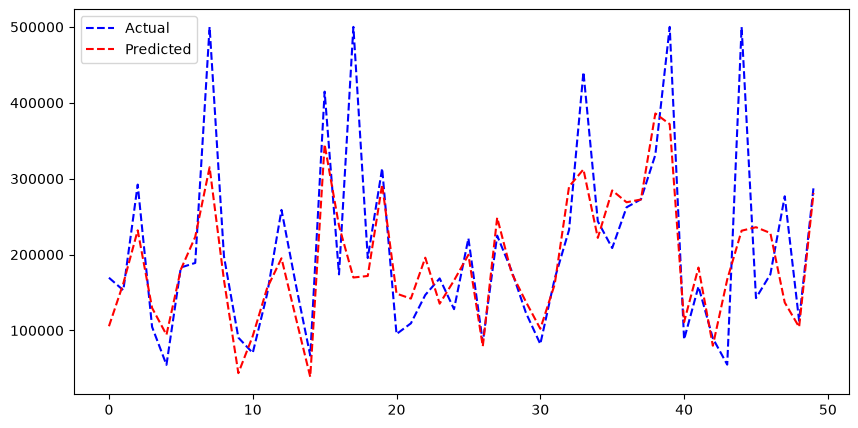

In [83]:
X_new = X_test[:50] # pretend these are new instances

y_pred = model.predict(X_new)

plt.figure(figsize=(10,5))

plt.plot(np.arange(0,len(X_new),1),y_test[:50],'b--',label='Actual')
plt.plot(np.arange(0,len(X_new),1),y_pred,'r--',label='Predicted')
plt.legend()
plt.show()
plt.show()
#plt.scatter(y_test[:20],y_pred)


RESIDUAL PLOT

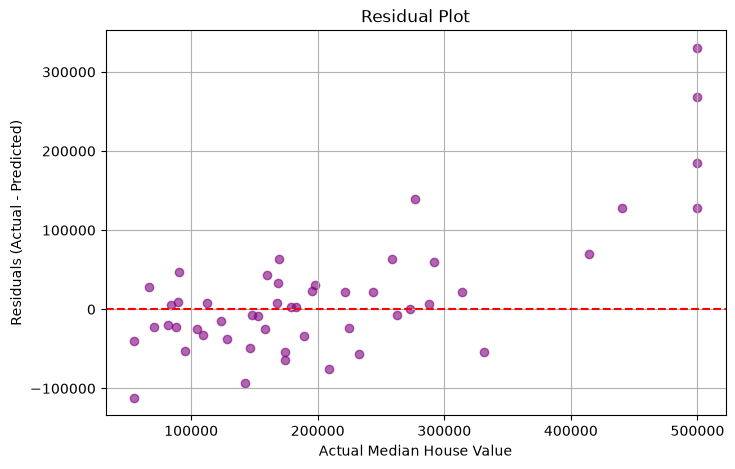

In [84]:
# RESIDUAL PLOT
residuals = y_test[:50] - y_pred.flatten()

plt.figure(figsize=(8, 5))
plt.scatter(y_test[:50], residuals, alpha=0.6, color='purple')
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Actual Median House Value")
plt.ylabel("Residuals (Actual - Predicted)")
plt.title("Residual Plot")
plt.grid(True)
plt.show()

# COMMENT:
# If residuals are randomly scattered around zero, it indicates a good fit.
# Patterns or curvature in the residuals would suggest model bias or missing nonlinearity.




Comment on residual plot
In this new residual plot:

X-axis: Actual house values (y_test)

Y-axis: Residuals = Actual − Predicted

Each point: one test sample

Red dashed line: Ideal zero-error reference line

Positive Observations:
No obvious pattern or curve in residuals → indicates that the model is likely capturing non-linear trends better than before.

Residuals are fairly symmetrically distributed above and below the red line.

The spread is tighter (residuals mostly between ±100,000), showing reduced error magnitude.

Remaining Concerns:
Slight heteroscedasticity: Residuals become more spread out as the actual house value increases. This suggests that the model might still be less accurate for higher-priced homes.

Some outliers: A few points (top and bottom) are still far from zero, possibly due to rare or extreme values in the dataset.

feature importance

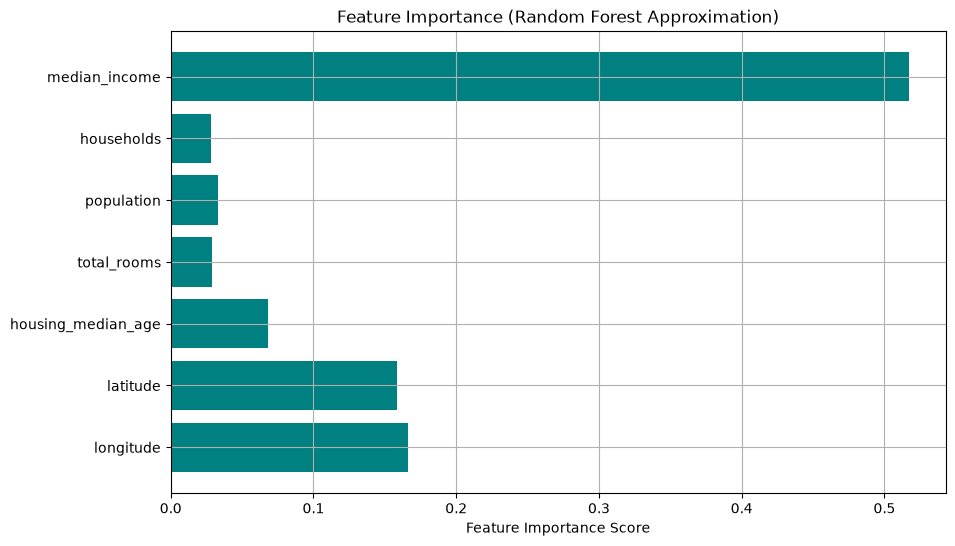

In [85]:
from sklearn.ensemble import RandomForestRegressor

# Fit a RandomForest model for feature importance
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

# Plot feature importances
importances = rf.feature_importances_
#feature_names = housing.columns.drop('median_house_value')  # since target was popped earlier
feature_names = housing.columns
plt.figure(figsize=(10, 6))
plt.barh(feature_names, importances, color='teal')
plt.xlabel("Feature Importance Score")
plt.title("Feature Importance (Random Forest Approximation)")
plt.grid(True)
plt.show()

# COMMENT:
# This helps interpret which features the model relies on most. Higher scores = more influence.


CORRELATION MATRIX

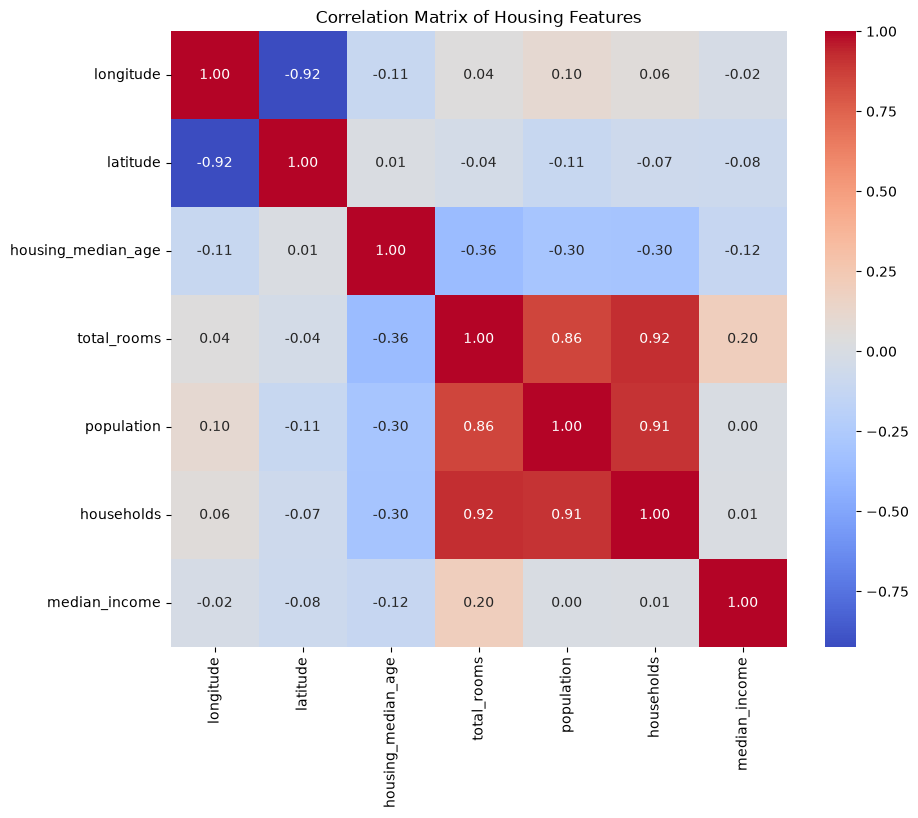

In [86]:
# CORRELATION MATRIX
import seaborn as sns

plt.figure(figsize=(10, 8))
corr_matrix = housing.corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", square=True)
plt.title("Correlation Matrix of Housing Features")
plt.show()

# COMMENT:
# Useful to detect multicollinearity (highly correlated inputs) or strong predictors of the target.


** Comments on Correlation Matrix**
This heatmap shows pairwise correlations between all numerical features in your housing dataset. It helps you understand which variables move together—and how strongly.

How to Read the Correlation Matrix: Range: Correlation values go from -1 to +1:

+1 = perfect positive correlation (move together) -1 = perfect negative correlation (move opposite) 0 = no linear relationship

Color:

Red = Strong positive Blue = Strong negative White = Weak or no correlation

Key Observations
Highly correlated pairs:
total_rooms ↔ households: 0.92 population ↔ households: 0.91 total_rooms ↔ population: 0.86

These features likely capture similar information (redundancy).
Strong negative correlation: longitude ↔ latitude: -0.92 This is geographic and expected due to layout of California.

Low correlation with target indicator (median_income):
Most features have weak correlation with median_income, except:
total_rooms: 0.20 Others are < 0.12, indicating limited direct linear influence.

[0.49987798]


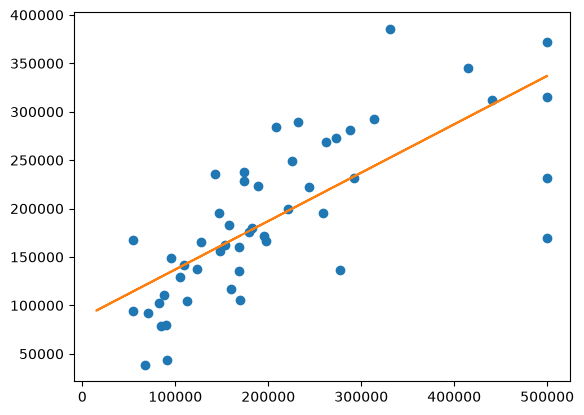

In [87]:
X_new = X_test[:50]
plt. plot(y_test[:50],y_pred, 'o')
m, b = np. polyfit(y_test[:50],y_pred, 1)
plt. plot(y_test, m*y_test+ b)
print(m)

Improve the model

In [88]:
model = keras.models.Sequential([
    keras.layers.Dense(14, activation="relu", input_shape=(7,)), # First hidden layer
    keras.layers.Dense(1)                                        # Output layer
])

model.summary()


model.compile(loss="mse", optimizer="sgd")


history = model.fit(X_train, y_train, epochs=50,verbose=1)

c:\Users\sudar\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_16 (Dense)                │ (None, 14)             │           112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 1)              │            15 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 127 (508.00 B)

 Trainable params: 127 (508.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
484/484 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: inf   
Epoch 2/50
484/484 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 15263331895067984319825838080.0000
Epoch 3/50
484/484 ━━━━━━━━━━━━━━━━━━━━ 1s 993us/step - loss: 49033358757414830080.0000
Epoch 4/50
484/484 ━━━━━━━━━━━━━━━━━━━━ 0s 752us/step - loss: 170648453120.0000
Epoch 5/50
484/484 ━━━━━━━━━━━━━━━━━━━━ 0s 759us/step - loss: 13436595200.0000
Epoch 6/50
484/484 ━━━━━━━━━━━━━━━━━━━━ 0s 828us/step - loss: 13434354688.0000
Epoch 7/50
484/484 ━━━━━━━━━━━━━━━━━━━━ 0s 786us/step - loss: 13435350016.0000
Epoch 8/50
484/484 ━━━━━━━━━━━━━━━━━━━━ 0s 792us/step - loss: 13436844032.0000
Epoch 9/50
484/484 ━━━━━━━━━━━━━━━━━━━━ 0s 915us/step - loss: 13435667456.0000
Epoch 10/50
484/484 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 13432511488.0000
Epoch 11/50
484/484 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 13434565632.0000 
Epoch 12/50
484/484 ━━━━━━━━━━━━━━━━━━━━ 0s 853us/step - loss: 13435687936.0000
Epoch 13/50
484/484 ━━━━━━━━━━━━━━━━━━

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step


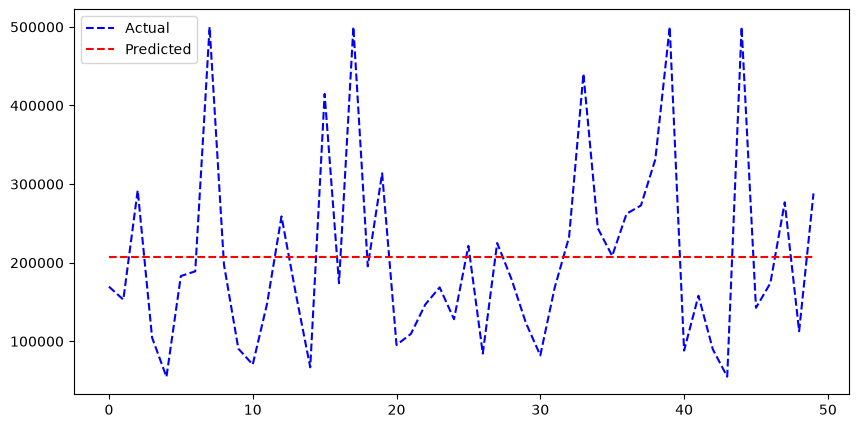

In [89]:
X_new = X_test[:50] # pretend these are new instances

y_pred = model.predict(X_new)

plt.figure(figsize=(10,5))

plt.plot(np.arange(0,len(X_new),1),y_test[:50],'b--',label='Actual')
plt.plot(np.arange(0,len(X_new),1),y_pred,'r--',label='Predicted')
plt.legend()
plt.show()
plt.show()
#plt.scatter(y_test[:20],y_pred)

[-3.85258578e-16]


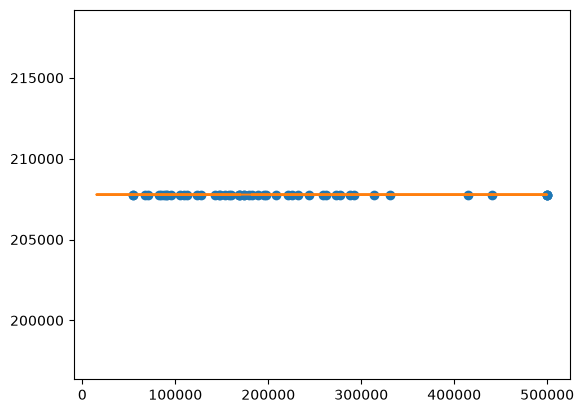

In [90]:
X_new = X_test[:50]
plt. plot(y_test[:50],y_pred, 'o')
m, b = np. polyfit(y_test[:50],y_pred, 1)
plt. plot(y_test, m*y_test+ b)
print(m)

# change optimizer


In [91]:
model = keras.models.Sequential([
    keras.layers.Dense(14, activation="relu", input_shape=(7,)), # First hidden layer
    keras.layers.Dense(1)                                        # Output layer
])

model.summary()


model.compile(loss="mae", optimizer="adam", metrics= ['mae'] )


history = model.fit(X_train, y_train, epochs=50,verbose=1)

Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_18 (Dense)                │ (None, 14)             │           112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 1)              │            15 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 127 (508.00 B)

 Trainable params: 127 (508.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
484/484 ━━━━━━━━━━━━━━━━━━━━ 1s 849us/step - loss: 207316.8750 - mae: 207316.8750
Epoch 2/50
484/484 ━━━━━━━━━━━━━━━━━━━━ 0s 828us/step - loss: 207291.5312 - mae: 207291.5312
Epoch 3/50
484/484 ━━━━━━━━━━━━━━━━━━━━ 0s 875us/step - loss: 207244.2812 - mae: 207244.2812
Epoch 4/50
484/484 ━━━━━━━━━━━━━━━━━━━━ 1s 909us/step - loss: 207173.9375 - mae: 207173.9375
Epoch 5/50
484/484 ━━━━━━━━━━━━━━━━━━━━ 1s 999us/step - loss: 207085.7656 - mae: 207085.7656
Epoch 6/50
484/484 ━━━━━━━━━━━━━━━━━━━━ 1s 990us/step - loss: 206981.7188 - mae: 206981.7188
Epoch 7/50
484/484 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 206863.3750 - mae: 206863.3750  
Epoch 8/50
484/484 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 206731.3438 - mae: 206731.3438  
Epoch 9/50
484/484 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 206586.6250 - mae: 206586.6250
Epoch 10/50
484/484 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 206429.5156 - mae: 206429.5156  
Epoch 11/50
484/484 ━━━━━━━━━━━━━━━━━━━━ 0s 896us/step - loss: 206259.8

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step


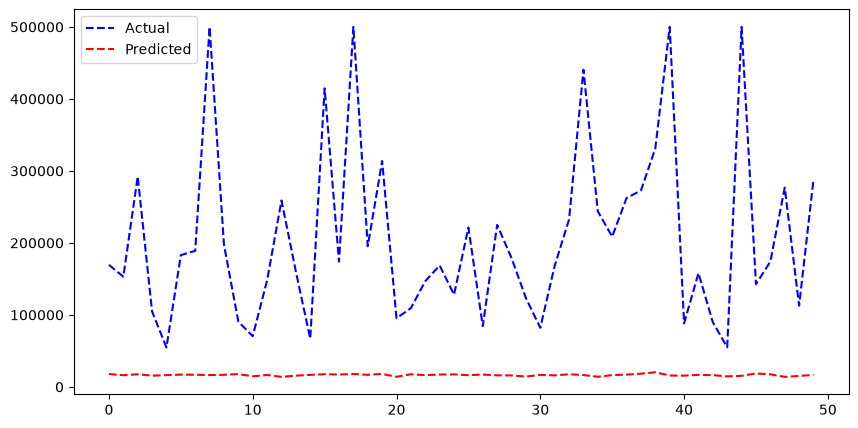

In [92]:
X_new = X_test[:50] # pretend these are new instances

y_pred = model.predict(X_new)

plt.figure(figsize=(10,5))

plt.plot(np.arange(0,len(X_new),1),y_test[:50],'b--',label='Actual')
plt.plot(np.arange(0,len(X_new),1),y_pred,'r--',label='Predicted')
plt.legend()
plt.show()
plt.show()
#plt.scatter(y_test[:20],y_pred)


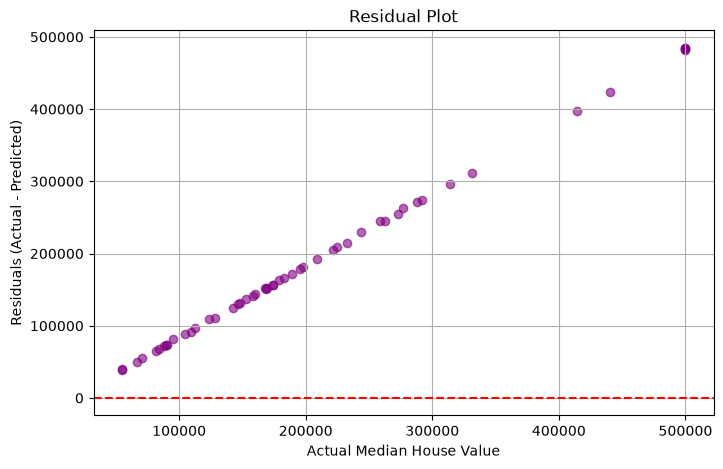

In [93]:
# RESIDUAL PLOT
residuals = y_test[:50] - y_pred.flatten()

plt.figure(figsize=(8, 5))
plt.scatter(y_test[:50], residuals, alpha=0.6, color='purple')
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Actual Median House Value")
plt.ylabel("Residuals (Actual - Predicted)")
plt.title("Residual Plot")
plt.grid(True)
plt.show()

# COMMENT:
# If residuals are randomly scattered around zero, it indicates a good fit.
# Patterns or curvature in the residuals would suggest model bias or missing nonlinearity.




Comments
Pattern observed:
Residuals increase consistently as the actual house value increases.

All residuals are positive → model systematically underpredicts for all data points.

The residuals form a nearly perfectly upward-sloping line.

What this suggests:
Model Bias (Underfitting):

The model isn't capturing the true underlying relationship between input features and output.

It's consistently predicting values lower than the actual values, especially for high-value homes.

Nonlinearity Not Captured:

The data likely contains non-linear patterns that your simple model (with just 1 hidden layer) can't learn.

A linear or shallow model isn't flexible enough.

Potential Feature Scaling or Limiting Issue:

If your model was trained on normalized features, but predictions are unscaled or incomplete, it can affect interpretation.

[0.00174551]


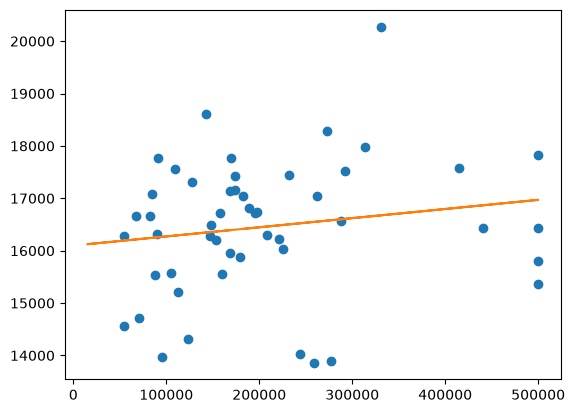

In [95]:
X_new = X_test[:50]
plt. plot(y_test[:50],y_pred, 'o')
m, b = np. polyfit(y_test[:50],y_pred, 1)
plt. plot(y_test, m*y_test+ b)
print(m)

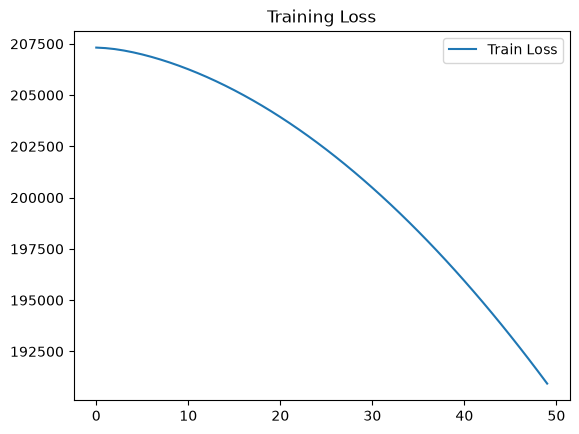

In [99]:
plt.plot(history.history['loss'], label='Train Loss')
plt.title("Training Loss")
plt.legend()
plt.show()

Change the hidden neurons from 14 to 50, use MAE loss, SGD optimizer, and observe the graph.

In [100]:
model = tf.keras.Sequential([
    tf.keras.layers.Dense(50, activation='relu', input_shape=(X_train.shape[1],)),
    tf.keras.layers.Dense(1)
])

In [101]:
model.compile(
    optimizer='sgd',
    loss='mae',
    metrics=['mae']
)

In [104]:
print(X_train.shape)

try:
    print(Y_train.shape)
except:
    print("Y_train does not exist")

try:
    print(y_train.shape)
except:
    print("y_train does not exist")

(15480, 7)
Y_train does not exist
(15480,)


In [107]:
history = model.fit(
    X_train,
    y_train,
    epochs=200,
    validation_split=0.2,
    verbose=1
)

Epoch 1/200
387/387 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 207022.4062 - mae: 207022.4062 - val_loss: 194744.2500 - val_mae: 194744.2500
Epoch 2/200
387/387 ━━━━━━━━━━━━━━━━━━━━ 0s 863us/step - loss: 109207.1016 - mae: 109207.1016 - val_loss: 84012.1562 - val_mae: 84012.1562
Epoch 3/200
387/387 ━━━━━━━━━━━━━━━━━━━━ 0s 820us/step - loss: 84960.0859 - mae: 84960.0859 - val_loss: 80765.1094 - val_mae: 80765.1094
Epoch 4/200
387/387 ━━━━━━━━━━━━━━━━━━━━ 0s 854us/step - loss: 81186.9766 - mae: 81186.9766 - val_loss: 76852.7266 - val_mae: 76852.7266
Epoch 5/200
387/387 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 76186.5547 - mae: 76186.5547 - val_loss: 71195.9766 - val_mae: 71195.9766
Epoch 6/200
387/387 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 69475.4453 - mae: 69475.4453 - val_loss: 63985.6992 - val_mae: 63985.6992
Epoch 7/200
387/387 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 61939.7500 - mae: 61939.7500 - val_loss: 57586.1875 - val_mae: 57586.1875
Epoch 8/200
387/387 ━━━━━━━━━━━━━━━━━━━━ 1s

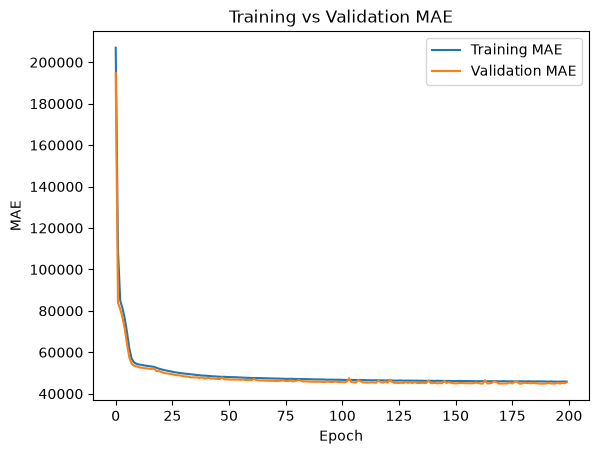

In [108]:
import matplotlib.pyplot as plt

plt.plot(history.history['loss'], label='Training MAE')
plt.plot(history.history['val_loss'], label='Validation MAE')
plt.title("Training vs Validation MAE")
plt.xlabel("Epoch")
plt.ylabel("MAE")
plt.legend()
plt.show()

Add three hidden layers with 32, 128, 64 neurons, use MAE loss and SGD optimizer.

In [109]:
model = tf.keras.Sequential([
    tf.keras.layers.Dense(32, activation='relu', input_shape=(X_train.shape[1],)),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(1)
])

In [110]:
model.compile(
    optimizer='sgd',
    loss='mae',
    metrics=['mae']
)

In [114]:
print("X_train exists:", "X_train" in globals())
print("Y_train exists:", "Y_train" in globals())
print("y_train exists:", "y_train" in globals())
print("X_test exists:", "X_test" in globals())
print("Y_test exists:", "Y_test" in globals())
print("y_test exists:", "y_test" in globals())
%who

X_train exists: True
Y_train exists: False
y_train exists: True
X_test exists: True
Y_test exists: False
y_test exists: True
RandomForestRegressor	 X	 X_new	 X_test	 X_train	 Y	 b	 corr_matrix	 feature_names	 
history	 hnorm	 housing	 htest	 importances	 keras	 m	 model	 np	 
pd	 plt	 residuals	 rf	 sns	 target	 tf	 train_test_split	 y_pred	 
y_test	 y_train	 


In [116]:
history = model.fit(
    X_train,
    y_train,
    epochs=200,
    validation_split=0.2,
    verbose=1
)

Epoch 1/200
387/387 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 214128.2500 - mae: 214128.2500 - val_loss: 204612.6094 - val_mae: 204612.6094
Epoch 2/200
387/387 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 207993.0000 - mae: 207993.0000 - val_loss: 204608.7188 - val_mae: 204608.7188
Epoch 3/200
387/387 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 207988.9219 - mae: 207988.9219 - val_loss: 204604.8125 - val_mae: 204604.8125
Epoch 4/200
387/387 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 207985.2344 - mae: 207985.2344 - val_loss: 204600.9531 - val_mae: 204600.9531
Epoch 5/200
387/387 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 207981.1719 - mae: 207981.1719 - val_loss: 204597.1094 - val_mae: 204597.1094
Epoch 6/200
387/387 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 207977.4062 - mae: 207977.4062 - val_loss: 204593.2344 - val_mae: 204593.2344
Epoch 7/200
387/387 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 207973.5156 - mae: 207973.5156 - val_loss: 204589.3594 - val_mae: 204589.3594
Epoch 8/200
387/387 ━━━━━━━

In [118]:
model.evaluate(X_test, y_test)

162/162 ━━━━━━━━━━━━━━━━━━━━ 0s 982us/step - loss: 204682.3438 - mae: 204682.3438


[204682.34375, 204682.34375]

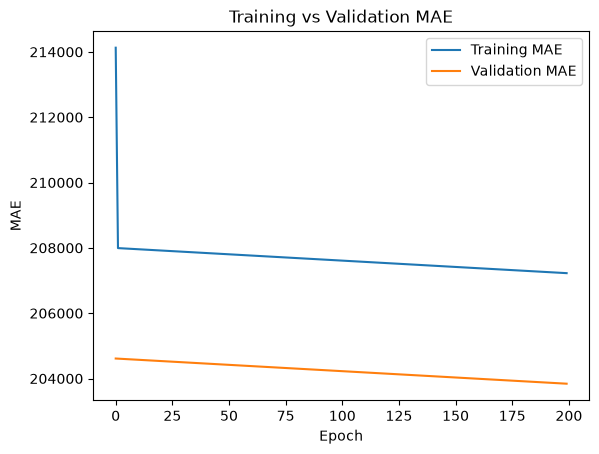

In [119]:
import matplotlib.pyplot as plt

plt.plot(history.history['loss'], label='Training MAE')
plt.plot(history.history['val_loss'], label='Validation MAE')

plt.title("Training vs Validation MAE")
plt.xlabel("Epoch")
plt.ylabel("MAE")
plt.legend()
plt.show()
